In [1]:
import torch
from torch.nn.functional import threshold

from models import ou_model, logistic_model, simulate, plot_traj_set

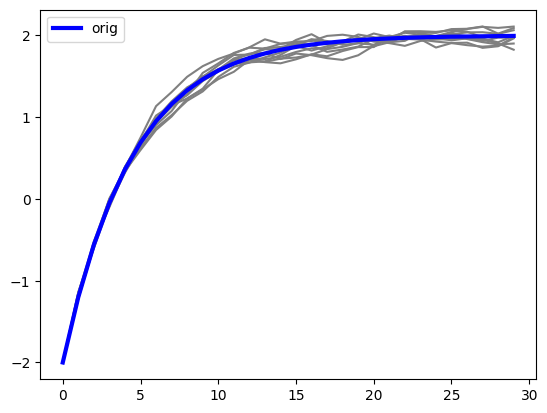

In [2]:
#ornstein uhlembeck process
# X_{t+1} = a*X_t + b + sigma*eps;  eps~normal(0,1)
time = 30
#fast convergence to x=2, with little noise
params = {'time': time,      # time steps
            'init_x':-2.,  # initial x
            'a': 0.8,        #
            'b': 0.4,       #
            'sigma': 0.22}

#slower convergence to x=2, higher variance
params2 = {'time': time,      # time steps
            'init_x':4.,  # initial x
            'a': 0.96,        #
            'b': 0.08,       #
            'sigma': 0.18}


params3 = {'time': time,      # time steps
            'init_x':0.,  # initial x
            'a': 0.9,        #
            'b': 0.0,       #
            'sigma': 0.4}

# Boolean
n_trajs = 10_000
trajs = simulate(ou_model, n_trajs, params)
plot_traj_set(trajs, single_traj=10, color='blue', label='orig')

# Robustness
time = 30
#fast convergence to x=2, with little noise
params = {'time': time,      # time steps
            'init_x':-2.,  # initial x
            'a': 0.88,        #
            'b': 0.24,       #
            'sigma': 0.22}
n_trajs = 10_000
trajs_robust = simulate(ou_model, n_trajs, params)

In [3]:
# Boolean monitor

threshold = 2.1
row_max = trajs.max(dim=1).values
tv = (row_max > threshold).int()
print('Estimated phi:', tv.float().mean(), '+-', tv.float().std()/n_trajs**0.5)

# Robustness monitor

threshold = 2.1
row_max = trajs_robust.max(dim=1).values
tv = (row_max - threshold)
print('Estimated phi:', tv.float().mean(), '+-', tv.float().std()/n_trajs**0.5)


Estimated phi: tensor(0.2913) +- tensor(0.0045)
Estimated phi: tensor(-0.1654) +- tensor(0.0009)


DeGAS section

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('../../../src'))

# import module optimization to use DeGAS
from optimization import *
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

c:\Users\frara\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Boolean

In [3]:
# COMPILING AND SMOOTHING THE CFG

# Compile SOGA program to a smooth CFG
compiledFile = compile2SOGA('ou-bool.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg, smooth_eps=1e-3)

# cfg represents now the smoothed program
# The cfg can be explored using the dictionary cfg.node_list

cfg.node_list

{'entry': EntryNode<>,
 'state0': StateNode<state0,None,X=-2,smoothed:X=-2+ gm([1.], [0.], [0.0010000000])>,
 'loop0': LoopNode<loop0>,
 'state1': StateNode<state1,True,X=0.8*X+0.4+gm([1.0],[0.000000],[0.048400])>,
 'test0': TestNode<test0,X>2.1>,
 'state2': StateNode<state2,True,phi=1,smoothed:phi=1+ gm([1.], [0.], [0.0010000000])>,
 'state3': StateNode<state3,False,skip>,
 'merge0': MergeNode<merge0>,
 'state4': StateNode<state4,None,skip>,
 'state5': StateNode<state5,False,skip>,
 'exit': ExitNode<>}

In [4]:
#run SOGA
output_dist = start_SOGA(cfg)
output_dist.gm.n_comp()

116256

In [5]:
output_dist.var_list

['X', 'phi']

In [6]:
#average value of phi
phi_idx = output_dist.var_list.index('phi')
phi_avg = output_dist.gm.mean()[phi_idx]
print('Mean phi:', phi_avg)

Mean phi: tensor(0.3418)


In [7]:
#average value of X
x_idx = output_dist.var_list.index('X')
x_avg = output_dist.gm.mean()[x_idx]
print('Mean X:', x_avg)

Mean X: tensor(1.9950)


Second Version

In [8]:
# COMPILING AND SMOOTHING THE CFG

# Compile SOGA program to a smooth CFG
compiledFile = compile2SOGA('ou-bool-1.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg, smooth_eps=0.)

# cfg represents now the smoothed program
# The cfg can be explored using the dictionary cfg.node_list

cfg.node_list

{'entry': EntryNode<>,
 'state0': StateNode<state0,None,X=-2.0,smoothed:X=-2.0+ gm([1.], [0.], [0.0000000000])>,
 'state1': StateNode<state1,None,phi=0,smoothed:phi=0+ gm([1.], [0.], [0.0000000000])>,
 'loop0': LoopNode<loop0>,
 'state2': StateNode<state2,True,newX=0.8*X+0.4+gm([1.0],[0.000000],[0.048400])>,
 'state3': StateNode<state3,None,X=newX,smoothed:X=newX+ gm([1.], [0.], [0.0000000000])>,
 'test0': TestNode<test0,newX>2.1>,
 'state4': StateNode<state4,True,phi=1,smoothed:phi=1+ gm([1.], [0.], [0.0000000000])>,
 'state5': StateNode<state5,False,skip>,
 'merge0': MergeNode<merge0>,
 'state6': StateNode<state6,None,skip>,
 'state7': StateNode<state7,False,skip>,
 'exit': ExitNode<>}

In [9]:
#run SOGA
output_dist = start_SOGA(cfg)
output_dist.gm.n_comp()

116256

In [10]:
output_dist.var_list

['X', 'phi', 'newX']

In [11]:
#average value of phi
phi_idx = output_dist.var_list.index('phi')
phi_avg = output_dist.gm.mean()[phi_idx]
print('Mean phi:', phi_avg)

Mean phi: tensor(0.3418)


In [12]:
#average value of X
x_idx = output_dist.var_list.index('X')
x_avg = output_dist.gm.mean()[x_idx]
print('Mean X:', x_avg)

Mean X: tensor(1.9950)


## Robustness

In [54]:
# COMPILING AND SMOOTHING THE CFG

# Compile SOGA program to a smooth CFG
compiledFile = compile2SOGA('ou-robustness.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

# cfg represents now the smoothed program
# The cfg can be explored using the dictionary cfg.node_list

cfg.node_list

{'entry': EntryNode<>,
 'state0': StateNode<state0,None,currX=-2.0,smoothed:currX=-2.0+ gm([1.], [0.], [0.0010000000])>,
 'state1': StateNode<state1,None,phi=currX-2.1,smoothed:phi=currX-2.1+ gm([1.], [0.], [0.0010000000])>,
 'loop0': LoopNode<loop0>,
 'state2': StateNode<state2,True,newX=0.88*currX+0.24+gm([1.0],[0.000000],[0.048400])>,
 'state3': StateNode<state3,None,atom=newX-2.1,smoothed:atom=newX-2.1+ gm([1.], [0.], [0.0010000000])>,
 'state4': StateNode<state4,None,check=phi-atom,smoothed:check=phi-atom+ gm([1.], [0.], [0.0010000000])>,
 'test0': TestNode<test0,check<0.0>,
 'state5': StateNode<state5,True,phi=atom,smoothed:phi=atom+ gm([1.], [0.], [0.0010000000])>,
 'state6': StateNode<state6,False,skip>,
 'merge0': MergeNode<merge0>,
 'state7': StateNode<state7,None,currX=newX,smoothed:currX=newX+ gm([1.], [0.], [0.0010000000])>,
 'state8': StateNode<state8,False,skip>,
 'exit': ExitNode<>}

In [55]:
#run SOGA
output_dist = start_SOGA(cfg)
output_dist.gm.n_comp()

Entering EntryNode<>
mean tensor([0., 0., 0., 0., 0.])
cov tensor([[1.0000e-05, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e-05, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e-05, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e-05, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e-05]])


Entering StateNode<state0,None,currX=-2.0,smoothed:currX=-2.0+ gm([1.], [0.], [0.0010000000])>
mean tensor([0., 0., 0., 0., 0.])
cov tensor([[1.0000e-05, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e-05, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e-05, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e-05, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e-05]])


Entering StateNode<state1,None,phi=currX-2.1,smoothed:phi=currX-2.1+ gm([1.], [0.], [0.0010000000])>
m

628605

In [56]:
#average value of phi
phi_idx = output_dist.var_list.index('phi')
phi_avg = output_dist.gm.mean()[phi_idx]
print('Mean phi:', phi_avg)

Mean phi: tensor(-0.1500)


### No monitor

In [8]:
# COMPILING AND SMOOTHING THE CFG

# Compile SOGA program to a smooth CFG
compiledFile = compile2SOGA('ou.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

# cfg represents now the smoothed program
# The cfg can be explored using the dictionary cfg.node_list

cfg.node_list

{'entry': EntryNode<>,
 'state0': StateNode<state0,None,currX=-2.0,smoothed:currX=-2.0+ gm([1.], [0.], [0.0010000000])>,
 'state1': StateNode<state1,None,phi=0,smoothed:phi=0+ gm([1.], [0.], [0.0010000000])>,
 'loop0': LoopNode<loop0>,
 'state2': StateNode<state2,True,X[i]=currX,smoothed:X[i]=currX+ gm([1.], [0.], [0.0010000000])>,
 'state3': StateNode<state3,None,newX=0.88*currX+0.24+gm([1.0],[0.000000],[0.048400])>,
 'state4': StateNode<state4,None,currX=newX,smoothed:currX=newX+ gm([1.], [0.], [0.0010000000])>,
 'state5': StateNode<state5,False,skip>,
 'exit': ExitNode<>}

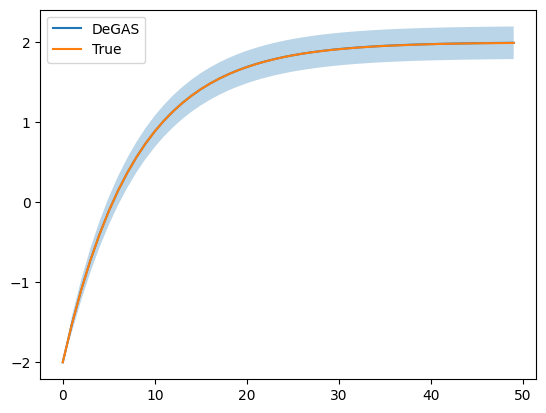

In [9]:
output_dist = start_SOGA(cfg)

vars = output_dist.gm.cov().diag()**0.5

T = 50
plt.plot(range(T), output_dist.gm.mean()[0:T], label='DeGAS')
plt.fill_between(range(T), output_dist.gm.mean()[0:T] - 2*vars[0:T], output_dist.gm.mean()[0:T] + 2*vars[0:T], alpha=0.3)
plt.plot(range(T), trajs.mean(dim=0), label='True')
plt.legend()

In [12]:
def extract_marginal(dist, idxs):
    """ Extract the marginal distribution of the variables in idxs from the multivariate Normal dist """
    new_vars = [dist.var_list[idx] for idx in idxs]
    new_mean = dist.gm.mu[:,idxs]
    new_cov = dist.gm.sigma[:, idxs][:, :, idxs]
    return Dist(new_vars, GaussianMix(torch.tensor([[1.]]), new_mean, new_cov))

def mvn_cdf_mc(mvn, upper):
    num_samples = int(1e7)
    samples = mvn.sample((num_samples,))
    # Check if each sample is less than or equal to the upper bound in all dimensions
    mask = (samples <= upper).all(dim=1)
    return mask.float().mean().item()



def p_above_threshold(dist, i, th):
    """ Given a multivariate Normal dist, compute the probability of P(x_i > th | xj < th for j < i) """

    n = len(dist.var_list)
    norm = torch.distributions.MultivariateNormal(dist.gm.mu[0], dist.gm.sigma[0])

    # first compute the normalizing constant by integrating x_i over (-inf, +inf) and all other variables over (-inf, th)
    # the formula simplifies to computing the cdf in (0,0,0, ..., inf)
    #y = torch.tensor([0. if j!=i else torch.inf for j in range(n)])
    #norm_const = mvn_cdf_mc(norm, y)
    #print('norm const', norm_const)

    # then computes the probability by integrating x_i over (th, +inf) and all other variables over (-inf, th) and dividing by normalizing constant
    # this formulas simplifies to
    y0 = torch.tensor([0. for _ in range(n)]) 
    y1 = torch.tensor([0. if j!=i else torch.inf for j in range(n)])
    prob = mvn_cdf_mc(norm, y1) - mvn_cdf_mc(norm, y0)
    print('prob: ', prob)

    return prob

def ghk_mvnorm_prob(mu, sigma, A, B, n_samples=10000, jitter=1e-8, generator=None):
    """
    Estimate P(A < X < B) for X ~ N(mu, sigma) with the GHK simulator.

    The bounds are centered internally by subtracting mu, so the algorithm
    runs on the equivalent zero-mean Gaussian.
    """
    mu = torch.as_tensor(mu)
    sigma = torch.as_tensor(sigma, dtype=mu.dtype, device=mu.device)
    A = torch.as_tensor(A, dtype=mu.dtype, device=mu.device).reshape(-1)
    B = torch.as_tensor(B, dtype=mu.dtype, device=mu.device).reshape(-1)
    mu = mu.reshape(-1)

    if mu.shape != A.shape or mu.shape != B.shape:
        raise ValueError("mu, A and B must have the same shape")
    if sigma.shape != (mu.numel(), mu.numel()):
        raise ValueError("sigma must have shape (k, k) where k = len(mu)")
    if torch.any(A >= B):
        return torch.zeros((), dtype=mu.dtype, device=mu.device)
    if n_samples <= 0:
        raise ValueError("n_samples must be positive")

    centered_A = A - mu
    centered_B = B - mu

    sigma = make_sym(sigma)
    eye = torch.eye(mu.numel(), dtype=mu.dtype, device=mu.device)
    chol = None
    current_jitter = jitter
    for _ in range(6):
        chol, info = torch.linalg.cholesky_ex(sigma + current_jitter * eye)
        if info.item() == 0:
            break
        current_jitter *= 10
    if chol is None or info.item() != 0:
        raise ValueError("sigma is not positive definite, even after diagonal jitter")

    normal = distributions.Normal(
        torch.tensor(0.0, dtype=mu.dtype, device=mu.device),
        torch.tensor(1.0, dtype=mu.dtype, device=mu.device),
    )
    finfo = torch.finfo(mu.dtype)
    u_eps = max(finfo.eps, 1e-12)

    dim = mu.numel()
    eps = torch.zeros((n_samples, dim), dtype=mu.dtype, device=mu.device)
    log_q = torch.zeros(n_samples, dtype=mu.dtype, device=mu.device)
    alive = torch.ones(n_samples, dtype=torch.bool, device=mu.device)

    for i in range(dim):
        if i == 0:
            shift = torch.zeros(n_samples, dtype=mu.dtype, device=mu.device)
        else:
            shift = eps[:, :i] @ chol[i, :i]

        a_i = centered_A[i] - shift
        b_i = centered_B[i] - shift
        alpha = a_i / chol[i, i]
        beta = b_i / chol[i, i]

        cdf_alpha = normal.cdf(alpha)
        cdf_beta = normal.cdf(beta)
        q_i = cdf_beta - cdf_alpha

        valid = torch.isfinite(q_i) & (q_i > 0)
        alive = alive & valid
        safe_q_i = torch.where(valid, q_i, torch.ones_like(q_i))
        log_q = log_q + torch.where(valid, torch.log(safe_q_i), torch.zeros_like(log_q))

        u = torch.rand(n_samples, dtype=mu.dtype, device=mu.device, generator=generator)
        truncated_u = cdf_alpha + u * safe_q_i
        truncated_u = torch.clamp(truncated_u, min=u_eps, max=1 - u_eps)
        eps[:, i] = torch.where(alive, normal.icdf(truncated_u), torch.zeros_like(truncated_u))

    weights = torch.where(alive, torch.exp(log_q), torch.zeros_like(log_q))
    return weights.mean()

In [19]:

from time import time 

idxs = [i for i in range(T)]
traj_dist = extract_marginal(output_dist, idxs)
n = len(traj_dist.var_list)
y = torch.tensor([2.1 for _ in range(n)])
low = torch.tensor([-torch.inf for _ in range(n)])
traj_norm = torch.distributions.MultivariateNormal(traj_dist.gm.mu[0], traj_dist.gm.sigma[0])
#1 - mvn_cdf_mc(traj_norm, y)
start = time()
print('prob:', 1 - ghk_mvnorm_prob(traj_dist.gm.mu[0], traj_dist.gm.sigma[0], low, y))
end = time()
print(end-start)

prob: tensor(0.4686)
0.02940082550048828
